# PSBD end to end

This notebook runs the whole method on 1 backdoored model, step by step and draws every intermediate quantity: the splits, the unperturbed baseline, the perturbed passes, the score of every image, the rate the rule picks, the threshold and the verdict. It runs both named placements, PSBD-TM (`before_attention_norm`, `token_mask`) and PSBD-RD (`post_residual`, `dropout`), on `vit_cifar100_badnet_a2o_0_01`, a ViT-B/16 trained on CIFAR-100 with BadNets all-to-one at 1% poisoning and target class 0.

The GPU half of PSBD is the perturbed forward passes, which `cli.sweep` already ran and cached under `results/vit_cifar100_badnet_a2o_0_01/psbd/`. This notebook repeats the CPU half, `cli.analyze`, on that cache with the same library functions, and checks at each step that it lands on the numbers `cli.analyze` wrote to `psbd_metrics.json`. It needs no GPU and runs in under a minute. The earlier version of this notebook re-ran the sweep on 800 images at 8 rates, and its numbers differed from the cache for that reason alone.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

import torch

from attacks import build_attack, default_config
from data.registry import DATASET_REGISTRY
from defenses.cache import (
    baseline_path,
    dropout_pass_path,
    load_baseline,
    load_dropout_pass_probs,
    read_run_provenance,
    read_split_manifest,
)
from data.splits import PSBD_HELDOUT_SIZE, PSBD_SPLIT_SEED
from defenses.decision import (
    ADAPTIVE_SHIFT_TARGET,
    HEADLINE_QUANTILE,
    PLACEMENT_MATCH_TARGET,
    PSBD_QUANTILES,
    PUBLISHED_PLACEMENT,
    RECOMMENDED_PLACEMENT,
    complete_rates,
    detection_report,
    pair_clean_to_backdoor,
    select_rate_adaptively,
    select_rate_at_matched_shift,
    select_rate_by_oracle,
    threshold_at_quantile,
)
from defenses.operators import TokenMask
from defenses.scores import psu_from_cache, psu_ratio_from_cache, shift_ratio, shift_target_histogram
from evaluation.loaders import load_test_base

FOLDER = "vit_cifar100_badnet_a2o_0_01"
PSBD_DIR = f"results/{FOLDER}/psbd"
SPLITS = ("validation", "clean", "backdoor")
PLACEMENTS = {"PSBD-TM": RECOMMENDED_PLACEMENT, "PSBD-RD": PUBLISHED_PLACEMENT}
PLACEMENT_COLORS = {"PSBD-TM": "#009E73", "PSBD-RD": "#D55E00"}
HEADLINE_KEY = f"q{HEADLINE_QUANTILE:.2f}"

with open(f"results/{FOLDER}/psbd_metrics.json") as handle:
    stored_report = json.load(handle)
with open(f"checkpoints/{FOLDER}/args.json") as handle:
    training_args = json.load(handle)
print({key: training_args[key] for key in ("dataset", "attack", "label_mode", "target_label", "poison_rate", "epochs", "seed")})

{'dataset': 'cifar100', 'attack': 'badnet_a2o', 'label_mode': 'all_to_one', 'target_label': 0, 'poison_rate': 0.01, 'epochs': 15, 'seed': None}


## The pipeline being run

The diagram is the map for the rest of the notebook. Each section below computes 1 box, for both placements and draws what that box produced.

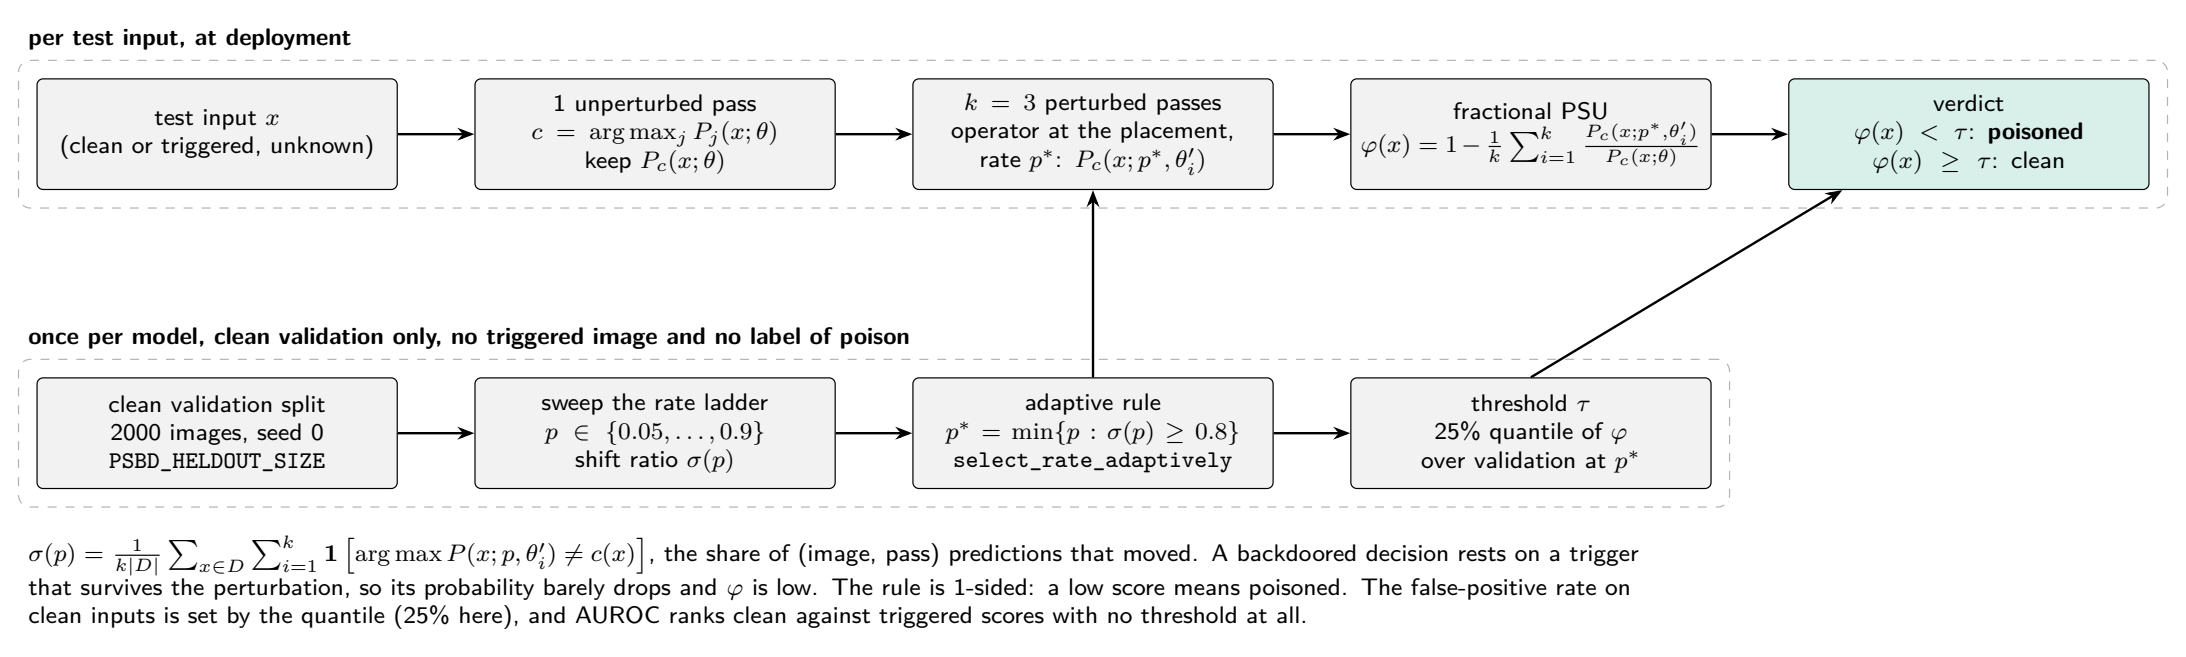

In [2]:
show_diagram("psbd_pipeline")

## The 3 splits

In [3]:
display(Markdown(rf"""
The defender's clean data and the images being judged must not overlap, or the threshold would be fitted on the very images it scores. `cli.sweep` builds the splits once per model through `data.splits.build_psbd_loaders_from_checkpoint` and records them in `split_manifest.json`. A fixed permutation of the test images, drawn with `seed_everything({PSBD_SPLIT_SEED})` (`PSBD_SPLIT_SEED`), gives the first {PSBD_HELDOUT_SIZE} images to the **validation** split (`PSBD_HELDOUT_SIZE`), which only ever sets the rate and the threshold. The rest form the **analysis** pool. Its **clean** split is those images as they are, and its **backdoor** split is the same images with the trigger stamped on, restricted to the ones the attack is allowed to target (`is_eval_poisonable`, for an all-to-one attack every image not already of the target class). The 2 analysis splits are paired image for image by `pair_clean_to_backdoor`, so a detection number compares an image with its own triggered copy.
"""))


The defender's clean data and the images being judged must not overlap, or the threshold would be fitted on the very images it scores. `cli.sweep` builds the splits once per model through `data.splits.build_psbd_loaders_from_checkpoint` and records them in `split_manifest.json`. A fixed permutation of the test images, drawn with `seed_everything(0)` (`PSBD_SPLIT_SEED`), gives the first 2000 images to the **validation** split (`PSBD_HELDOUT_SIZE`), which only ever sets the rate and the threshold. The rest form the **analysis** pool. Its **clean** split is those images as they are, and its **backdoor** split is the same images with the trigger stamped on, restricted to the ones the attack is allowed to target (`is_eval_poisonable`, for an all-to-one attack every image not already of the target class). The 2 analysis splits are paired image for image by `pair_clean_to_backdoor`, so a detection number compares an image with its own triggered copy.


In [4]:
manifest = read_split_manifest(PSBD_DIR)
heldout = set(manifest["heldout_indices"])
analysis_clean = manifest["analysis_clean_indices"]
analysis_backdoor = manifest["analysis_backdoor_indices"]
assert heldout.isdisjoint(analysis_clean)
assert set(analysis_backdoor) <= set(analysis_clean)

split_sizes = {"validation": len(heldout), "clean": len(analysis_clean), "backdoor": len(analysis_backdoor)}
assert split_sizes == stored_report["split_sizes"]
print("manifest:", {k: manifest[k] for k in ("seed", "dataset", "probe_attack", "probe_target_label", "label_mode", "n_total")})
print("split sizes:", split_sizes)
print("recipe:", manifest["recipe_note"])

manifest: {'seed': 0, 'dataset': 'cifar100', 'probe_attack': 'badnet_a2o', 'probe_target_label': 0, 'label_mode': 'all_to_one', 'n_total': 10000}
split sizes: {'validation': 2000, 'clean': 8000, 'backdoor': 7915}
recipe: seed_everything(seed); perm = torch.randperm(n_total); heldout = perm[:n_heldout]; analysis = perm[n_heldout:]


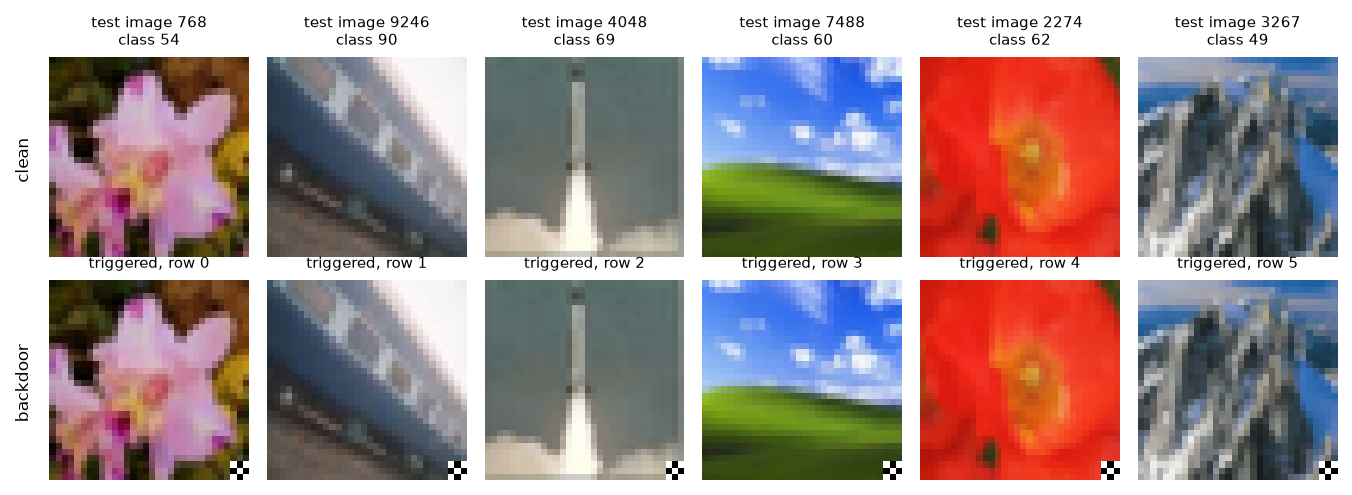

In [5]:
dataset = manifest["dataset"]
spec = DATASET_REGISTRY[dataset]
test_base, _ = load_test_base(dataset, "raw_data")
attack = build_attack(manifest["probe_attack"], default_config(manifest["probe_attack"]), spec.image_size, manifest["probe_target_label"])

shown_rows = [0, 1, 2, 3, 4, 5]
figure, axes = plt.subplots(2, len(shown_rows), figsize=(9.0, 3.3))
for column, row in enumerate(shown_rows):
    index = analysis_backdoor[row]
    image, label = test_base[index]
    triggered = attack.apply_trigger(image, index)  # (3, 32, 32)
    axes[0, column].imshow(image.permute(1, 2, 0).numpy(), interpolation="nearest")
    axes[0, column].set_title(f"test image {index}\nclass {label}", fontsize=7)
    axes[1, column].imshow(triggered.permute(1, 2, 0).clamp(0, 1).numpy(), interpolation="nearest")
    axes[1, column].set_title(f"triggered, row {row}", fontsize=7)
for axis in axes.flat:
    axis.axis("off")
axes[0, 0].text(-6, 16, "clean", rotation=90, va="center", fontsize=8)
axes[1, 0].text(-6, 16, "backdoor", rotation=90, va="center", fontsize=8)
figure.tight_layout()
plt.show()

In [6]:
display(Markdown(rf"""
The top row is the first {len(shown_rows)} rows of the backdoor split in their clean form and the bottom row the same images as the backdoor split serves them, the BadNets square in the bottom-right corner. These are what the 2 analysis splits contain, {split_sizes["backdoor"]} such pairs out of {split_sizes["clean"]} analysis images. The validation images look the same as the top row and never appear here. The figure does not show the resize to $224\times224$ the model applies before patching, which the token-mask figure below draws.
"""))


The top row is the first 6 rows of the backdoor split in their clean form and the bottom row the same images as the backdoor split serves them, the BadNets square in the bottom-right corner. These are what the 2 analysis splits contain, 7915 such pairs out of 8000 analysis images. The validation images look the same as the top row and never appear here. The figure does not show the resize to $224\times224$ the model applies before patching, which the token-mask figure below draws.


## The unperturbed baseline

Every PSU is a drop measured against the unperturbed pass, so `cli.sweep` runs it once per split before any placement is attached and saves `baseline_<split>.pt`: the $(n, \text{classes})$ softmax, its $(n,)$ argmax and the label the loader asked for. On the backdoor split that label is the attack's target, so baseline argmax equal to loader label is the per-image record of whether the trigger worked.

validation probs (2000, 100), argmax (2000,), loader labels (2000,)
clean      probs (8000, 100), argmax (8000,), loader labels (8000,)
backdoor   probs (7915, 100), argmax (7915,), loader labels (7915,)

attack success rate on the backdoor split, unperturbed: 1.0000
clean accuracy on the clean split, unperturbed:         0.8253


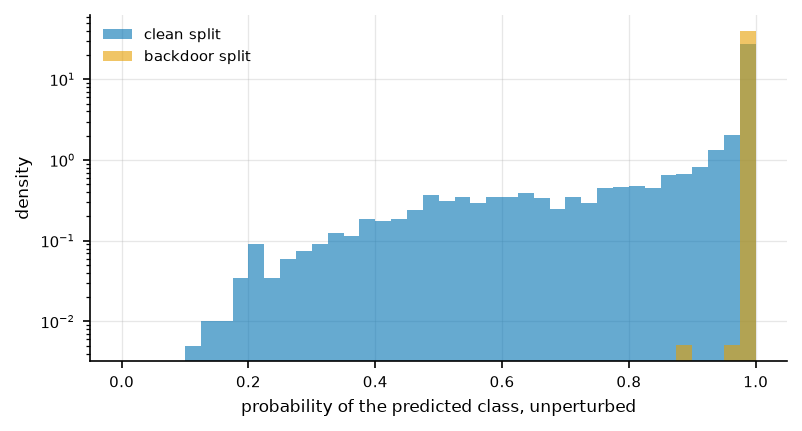

In [7]:
baselines = {split: load_baseline(baseline_path(PSBD_DIR, split)) for split in SPLITS}
for split, (probs, labels, loader_labels) in baselines.items():
    assert probs.shape == (split_sizes[split], spec.num_classes)
    print(f"{split:10s} probs {tuple(probs.shape)}, argmax {tuple(labels.shape)}, loader labels {tuple(loader_labels.shape)}")

backdoor_probs, backdoor_labels, backdoor_targets = baselines["backdoor"]
asr = (backdoor_labels == backdoor_targets).float().mean().item()
clean_probs, clean_labels, clean_targets = baselines["clean"]
clean_accuracy = (clean_labels == clean_targets).float().mean().item()
print(f"\nattack success rate on the backdoor split, unperturbed: {asr:.4f}")
print(f"clean accuracy on the clean split, unperturbed:         {clean_accuracy:.4f}")

confidence = {split: probs.gather(1, labels.view(-1, 1).long()).squeeze(1) for split, (probs, labels, _) in baselines.items()}  # (n,) each
figure, axis = plt.subplots(figsize=(6.0, 3.0))
bins = np.linspace(0, 1, 41)
for split in ("clean", "backdoor"):
    axis.hist(confidence[split].float().numpy(), bins=bins, alpha=0.6, density=True, label=f"{split} split")
axis.set_xlabel("probability of the predicted class, unperturbed")
axis.set_ylabel("density")
axis.set_yscale("log")
axis.legend()
plt.show()

clean_confidence_low = float(np.quantile(confidence["clean"].float().numpy(), 0.05))
backdoor_confidence_low = float(np.quantile(confidence["backdoor"].float().numpy(), 0.05))

In [8]:
display(Markdown(rf"""
The trigger works on {asr:.2%} of the backdoor split and the model keeps a clean accuracy of {clean_accuracy:.3f}. The histogram shows the objection PSU has to answer. 95% of triggered predictions sit above probability {backdoor_confidence_low:.3f}, while 5% of clean predictions sit below {clean_confidence_low:.3f}, so a detector reading confidence alone would already separate them to a degree. The fractional PSU below divides by this starting confidence so a confident clean image is not scored as poisoned merely for being confident. The figure does not show how the probability moves under a perturbation, which is the next step.
"""))


The trigger works on 100.00% of the backdoor split and the model keeps a clean accuracy of 0.825. The histogram shows the objection PSU has to answer. 95% of triggered predictions sit above probability 0.999, while 5% of clean predictions sit below 0.515, so a detector reading confidence alone would already separate them to a degree. The fractional PSU below divides by this starting confidence so a confident clean image is not scored as poisoned merely for being confident. The figure does not show how the probability moves under a perturbation, which is the next step.


## What 1 perturbed pass does

A placement attaches a fresh operator module at its position in every block through `models.positions.plug_dropout`, and each forward pass draws a new random mask in every block. The figure draws what `TokenMask`, at the adaptive rate `cli.analyze` stored for this model, does to the class token and 196 patch tokens of this image at the attention input of 3 of the 12 blocks of 1 pass, with the trigger's tokens outlined. It calls the library operator on a tensor of ones shaped like the real activation, $(1, 197, 768)$, so the masks are exactly the operator's and only the image content is borrowed.

trigger tokens (1 + patch index): [181, 182, 195, 196]


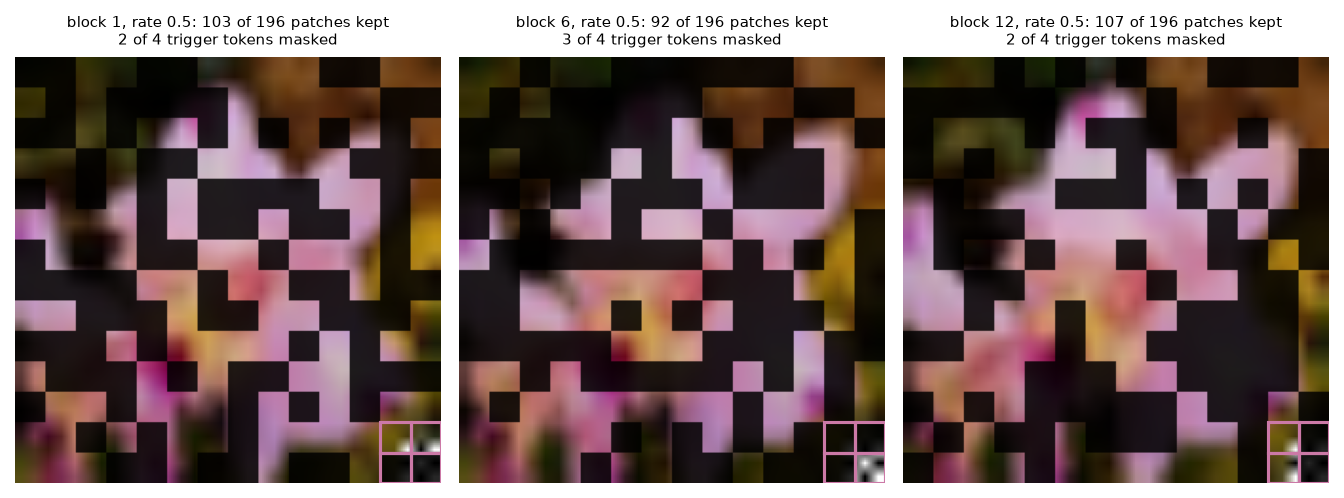

In [9]:
import torch.nn.functional as F

example_index = analysis_backdoor[0]
image, _ = test_base[example_index]
triggered = attack.apply_trigger(image, example_index)  # (3, 32, 32)
triggered_224 = F.interpolate(triggered[None], size=224, mode="bilinear", align_corners=False)[0]  # (3, 224, 224)

# A token belongs to the trigger when any pixel of its 16 by 16 patch changed.
difference_224 = F.interpolate((triggered - image).abs().sum(0)[None, None], size=224, mode="nearest")[0, 0]  # (224, 224)
patch_changed = difference_224.reshape(14, 16, 14, 16).amax(dim=(1, 3)) > 0  # (14, 14)
trigger_tokens = torch.nonzero(patch_changed.flatten()).flatten() + 1  # token ids, CLS is 0
print(f"trigger tokens (1 + patch index): {trigger_tokens.tolist()}")

torch.manual_seed(0)
mask_rate = stored_report["placements"][RECOMMENDED_PLACEMENT]["adaptive_rate"]
operator = TokenMask(mask_rate).train()
figure, axes = plt.subplots(1, 3, figsize=(9.0, 3.2))
for axis, block in zip(axes, (1, 6, 12)):
    kept = operator(torch.ones(1, 197, 768))[0, :, 0] > 0  # (197,), True where the token survives
    patch_kept = kept[1:].reshape(14, 14)  # (14, 14)
    shown = triggered_224.permute(1, 2, 0).clamp(0, 1).numpy().copy()  # (224, 224, 3)
    for row in range(14):
        for column in range(14):
            if not patch_kept[row, column]:
                shown[row * 16:(row + 1) * 16, column * 16:(column + 1) * 16] *= 0.15
    axis.imshow(shown)
    for token in trigger_tokens.tolist():
        row, column = divmod(token - 1, 14)
        axis.add_patch(plt.Rectangle((column * 16 - 0.5, row * 16 - 0.5), 16, 16, fill=False, edgecolor="#CC79A7", lw=1.5))
    trigger_masked = int((~kept[trigger_tokens]).sum())
    axis.set_title(f"block {block}, rate {mask_rate}: {int(kept[1:].sum())} of 196 patches kept\n{trigger_masked} of {len(trigger_tokens)} trigger tokens masked", fontsize=7)
    axis.axis("off")
figure.tight_layout()
plt.show()

Darkened patches are the tokens zeroed at the attention input of that block. The CLS token is never masked, and each block draws its own mask, so a trigger token hidden in 1 block is visible in the next. Because the skip carries every token forward untouched, the trigger's content survives as long as it is visible to attention in the blocks where the class token reads it, which `mechanism.ipynb` shows are the late blocks. That is why a triggered prediction survives most PSBD-TM passes while a clean prediction, which needs many tokens, does not. The figure is a single draw and does not show the prediction, which the cache below records for every pass of every image.

## The rate ladder and the shift ratio

`cli.sweep` swept each placement over a ladder of rates, with $k=3$ passes per rate and stored `rate_<p>_<split>.pt`: the $(3, n)$ probability each pass gave the unperturbed class, and the $(3, n)$ class each pass predicted. `run_<placement>.json` records the ladder, $k$, the seeds and the commit. From these the analysis computes, per rate and split, the absolute PSU (`psu_from_cache`), the fractional PSU (`psu_ratio_from_cache`) and the shift ratio $\sigma$ (`shift_ratio`), exactly as `cli.analyze.analyze_one_rate` does.

In [10]:
def measure_rate(placement, rate):
    measured = {}
    for split in SPLITS:
        probs, labels, _ = baselines[split]
        per_pass_probs, per_pass_argmax = load_dropout_pass_probs(dropout_pass_path(PSBD_DIR, placement, rate, split))  # (3, n) each
        measured[split] = {
            "psu": psu_from_cache(probs, labels, per_pass_probs),  # (n,)
            "psu_ratio": psu_ratio_from_cache(probs, labels, per_pass_probs),  # (n,)
            "sigma": shift_ratio(labels, per_pass_argmax),
            "argmax": per_pass_argmax,
        }
    return measured


swept = {}
for name, placement in PLACEMENTS.items():
    provenance = read_run_provenance(PSBD_DIR, placement)
    rates = complete_rates(PSBD_DIR, placement)
    swept[name] = {rate: measure_rate(placement, rate) for rate in rates}
    print(f"{name} ({placement}): {len(rates)} rates {rates[0]} to {rates[-1]}, "
          f"k={provenance['forward_passes']}, position {provenance['position']}, operator {provenance.get('operator', 'dropout')}, "
          f"commit {provenance['git_commit'][:8]}")

PSBD-TM (before_attention_norm_token_mask): 10 rates 0.05 to 0.9, k=3, position before_attention_norm, operator token_mask, commit c14f5653
PSBD-RD (post_residual): 16 rates 0.005 to 0.9, k=3, position post_residual, operator dropout, commit 168dcfe4


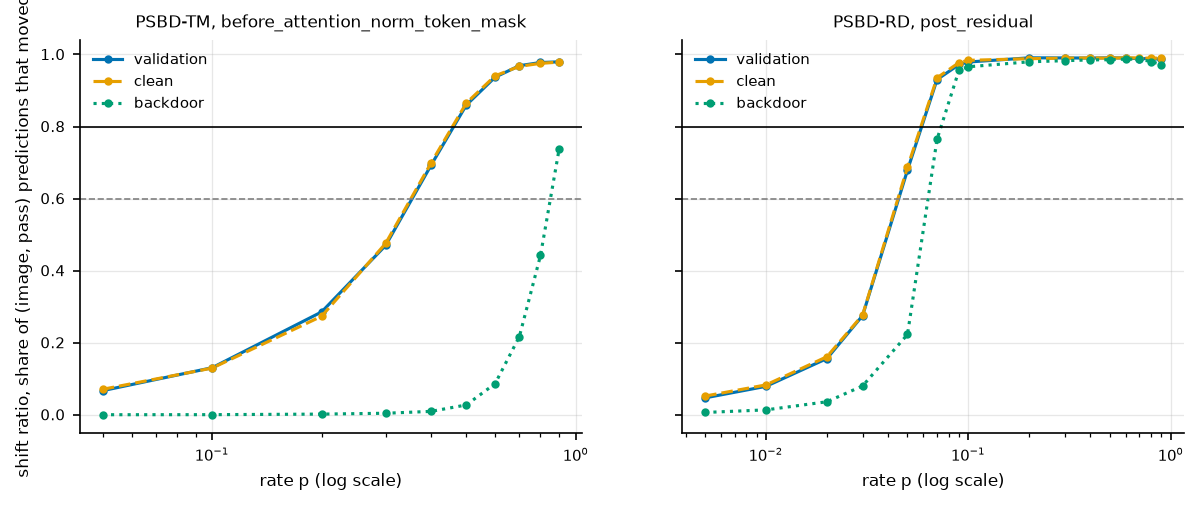

In [11]:
figure, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=True)
for axis, name in zip(axes, PLACEMENTS):
    rates = sorted(swept[name])
    for split, style in zip(SPLITS, ("-", "--", ":")):
        axis.plot(rates, [swept[name][r][split]["sigma"] for r in rates], marker="o", ms=3, ls=style, label=f"{split}")
    axis.axhline(ADAPTIVE_SHIFT_TARGET, color="black", lw=0.8)
    axis.axhline(PLACEMENT_MATCH_TARGET, color="gray", lw=0.8, ls="--")
    axis.set_xscale("log")
    axis.set_xlabel("rate p (log scale)")
    axis.set_title(f"{name}, {PLACEMENTS[name]}", fontsize=8)
    axis.legend()
axes[0].set_ylabel("shift ratio, share of (image, pass) predictions that moved")
plt.show()

adaptive_by_name = {name: select_rate_adaptively({r: swept[name][r]["validation"]["sigma"] for r in swept[name]}) for name in PLACEMENTS}
transfer_gap = max(abs(swept[n][r]["clean"]["sigma"] - swept[n][r]["validation"]["sigma"]) for n in PLACEMENTS for r in swept[n])
tm_backdoor_at_adaptive = swept["PSBD-TM"][adaptive_by_name["PSBD-TM"]]["backdoor"]["sigma"]
rd_backdoor_at_adaptive = swept["PSBD-RD"][adaptive_by_name["PSBD-RD"]]["backdoor"]["sigma"]

In [12]:
display(Markdown(rf"""
The solid line is what the defender sees, the clean validation split. The horizontal lines are the adaptive target {ADAPTIVE_SHIFT_TARGET} and the matched target {PLACEMENT_MATCH_TARGET}. 2 facts carry the method. First, the dashed clean analysis line sits on the validation line (the 2 never differ by more than {transfer_gap:.3f} at any rate), so the rate chosen on validation transfers to unseen clean images. Second, at its adaptive rate PSBD-TM moves {tm_backdoor_at_adaptive:.1%} of triggered predictions and PSBD-RD {rd_backdoor_at_adaptive:.1%}, so the triggered prediction survives token masking and not residual dropout. The 2 placements also need very different rates to disturb the clean model equally, {adaptive_by_name["PSBD-TM"]} for token masking and {adaptive_by_name["PSBD-RD"]} for dropout on the stream, which is why a comparison at a shared $p$ would be meaningless. The figure does not show how well the scores separate, the next step.
"""))


The solid line is what the defender sees, the clean validation split. The horizontal lines are the adaptive target 0.8 and the matched target 0.6. 2 facts carry the method. First, the dashed clean analysis line sits on the validation line (the 2 never differ by more than 0.012 at any rate), so the rate chosen on validation transfers to unseen clean images. Second, at its adaptive rate PSBD-TM moves 2.7% of triggered predictions and PSBD-RD 76.5%, so the triggered prediction survives token masking and not residual dropout. The 2 placements also need very different rates to disturb the clean model equally, 0.5 for token masking and 0.07 for dropout on the stream, which is why a comparison at a shared $p$ would be meaningless. The figure does not show how well the scores separate, the next step.


## The rule and the threshold

In [13]:
display(Markdown(rf"""
`select_rate_adaptively` picks the smallest rate whose validation $\sigma$ reaches {ADAPTIVE_SHIFT_TARGET}. `select_rate_at_matched_shift` picks the rate whose validation $\sigma$ is closest to {PLACEMENT_MATCH_TARGET}. The **oracle** rate is the one with the best AUROC in hindsight. No defender can choose it because it reads the triggered labels, and it is reported only as an upper bound. At each rate the threshold $\tau$ is the {HEADLINE_QUANTILE:.0%} quantile of validation PSU (`threshold_at_quantile`), and `detection_report` turns $\tau$ into TPR, FPR and AUROC on the backdoor split against its paired clean images.
"""))


`select_rate_adaptively` picks the smallest rate whose validation $\sigma$ reaches 0.8. `select_rate_at_matched_shift` picks the rate whose validation $\sigma$ is closest to 0.6. The **oracle** rate is the one with the best AUROC in hindsight. No defender can choose it because it reads the triggered labels, and it is reported only as an upper bound. At each rate the threshold $\tau$ is the 25% quantile of validation PSU (`threshold_at_quantile`), and `detection_report` turns $\tau$ into TPR, FPR and AUROC on the backdoor split against its paired clean images.


In [14]:
def report_at(name, rate, quantile, score="psu_ratio"):
    measured = swept[name][rate]
    paired_clean = pair_clean_to_backdoor(measured["clean"][score], manifest)  # (n_backdoor,)
    report = detection_report(measured["validation"][score], paired_clean, measured["backdoor"][score], quantile)
    return report


rule_rows = []
auroc_curves = {}
for name, placement in PLACEMENTS.items():
    rates = sorted(swept[name])
    shift_by_rate = {rate: swept[name][rate]["validation"]["sigma"] for rate in rates}
    auroc_curves[name] = {rate: report_at(name, rate, HEADLINE_QUANTILE)["auroc"] for rate in rates}
    adaptive_rate = select_rate_adaptively(shift_by_rate)
    matched_rate = select_rate_at_matched_shift(shift_by_rate, PLACEMENT_MATCH_TARGET)
    oracle_rate = select_rate_by_oracle(auroc_curves[name])

    stored = stored_report["placements"][placement]
    assert adaptive_rate == stored["adaptive_rate"]
    stored_row = next(row for row in stored["rates"] if row["rate"] == adaptive_rate)
    assert abs(auroc_curves[name][adaptive_rate] - stored_row["detection_psu_ratio"][HEADLINE_KEY]["auroc"]) < 1e-9
    rule_rows.append(
        {
            "placement": name,
            "adaptive_rate": adaptive_rate,
            "adaptive_auroc": auroc_curves[name][adaptive_rate],
            "matched_rate": matched_rate,
            "matched_auroc": auroc_curves[name][matched_rate],
            "oracle_rate": oracle_rate,
            "oracle_auroc": auroc_curves[name][oracle_rate],
        }
    )

rule_frame = pd.DataFrame(rule_rows).set_index("placement")
print("adaptive rates and AUROC match results/<folder>/psbd_metrics.json, detection_psu_ratio, q0.25")
rule_frame.round(4)

adaptive rates and AUROC match results/<folder>/psbd_metrics.json, detection_psu_ratio, q0.25


,adaptive_rate,adaptive_auroc,matched_rate,matched_auroc,oracle_rate,oracle_auroc
placement,,,,,,
PSBD-TM,0.50,0.9878,0.40,0.9605,0.60,0.9960
PSBD-RD,0.07,0.7438,0.05,0.8573,0.05,0.8573


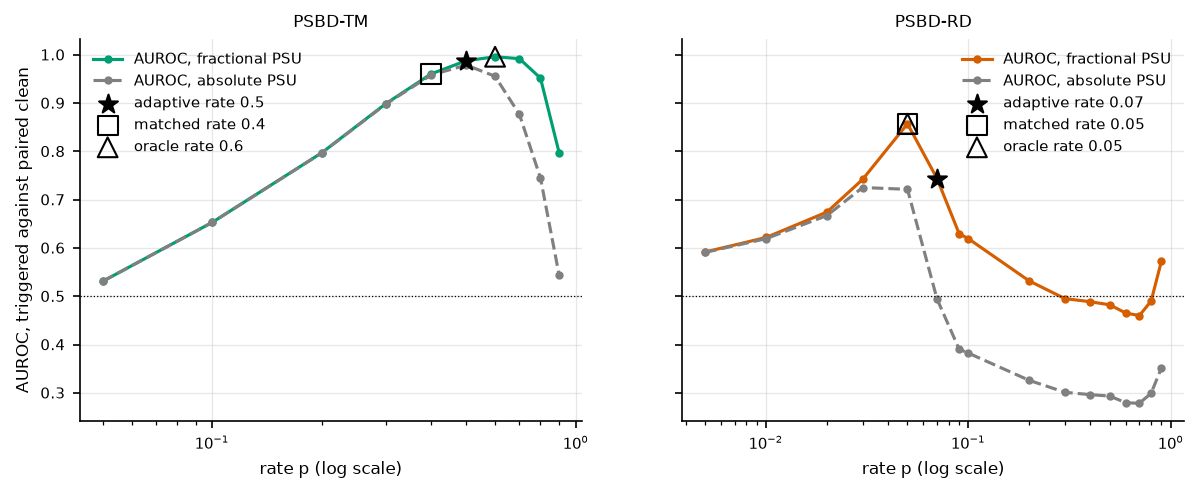

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(9.5, 3.3), sharey=True)
for axis, name in zip(axes, PLACEMENTS):
    rates = sorted(auroc_curves[name])
    axis.plot(rates, [auroc_curves[name][r] for r in rates], marker="o", ms=3, color=PLACEMENT_COLORS[name], label="AUROC, fractional PSU")
    absolute = [report_at(name, r, HEADLINE_QUANTILE, score="psu")["auroc"] for r in rates]
    axis.plot(rates, absolute, marker="o", ms=3, ls="--", color="gray", label="AUROC, absolute PSU")
    for rule, marker in (("adaptive", "*"), ("matched", "s"), ("oracle", "^")):
        rate = rule_frame.loc[name, f"{rule}_rate"]
        axis.scatter([rate], [auroc_curves[name][rate]], marker=marker, s=90, zorder=4, color="black", facecolor="none" if rule != "adaptive" else "black", label=f"{rule} rate {rate}")
    axis.axhline(0.5, color="black", lw=0.6, ls=":")
    axis.set_xscale("log")
    axis.set_xlabel("rate p (log scale)")
    axis.set_title(name, fontsize=8)
    axis.legend()
axes[0].set_ylabel("AUROC, triggered against paired clean")
plt.show()

tm_rates = sorted(auroc_curves["PSBD-TM"])
tm_good_from = min(r for r in tm_rates if all(auroc_curves["PSBD-TM"][q] >= 0.9 for q in tm_rates if r <= q <= rule_frame.loc["PSBD-TM", "oracle_rate"]))
rd_adaptive = rule_frame.loc["PSBD-RD", "adaptive_rate"]
rd_absolute_at_adaptive = report_at("PSBD-RD", rd_adaptive, HEADLINE_QUANTILE, score="psu")["auroc"]
rd_high_rates = [r for r in auroc_curves["PSBD-RD"] if r > 0.1]
rd_high_max = max(auroc_curves["PSBD-RD"][r] for r in rd_high_rates)

In [16]:
display(Markdown(rf"""
On this model PSBD-TM reads AUROC at least 0.9 from rate {tm_good_from} up to its oracle rate, and the adaptive rule (rate {rule_frame.loc["PSBD-TM", "adaptive_rate"]}, AUROC {rule_frame.loc["PSBD-TM", "adaptive_auroc"]:.3f}) lands close to the oracle (rate {rule_frame.loc["PSBD-TM", "oracle_rate"]}, {rule_frame.loc["PSBD-TM", "oracle_auroc"]:.3f}). PSBD-RD peaks at rate {rule_frame.loc["PSBD-RD", "oracle_rate"]} ({rule_frame.loc["PSBD-RD", "oracle_auroc"]:.3f}) and the adaptive rule picks rate {rd_adaptive}, where it reads {rule_frame.loc["PSBD-RD", "adaptive_auroc"]:.3f}. Above rate 0.1 it never exceeds {rd_high_max:.3f}, because dropout strong enough to move most clean predictions also breaks the triggered ones. The absolute PSU of PSBD-RD reads {rd_absolute_at_adaptive:.3f} at its adaptive rate, so dividing by the starting confidence recovers most of its signal. The oracle row can only be as good or better than the adaptive row, by construction, since it searches the same ladder with the labels a defender does not have, and the gap is the cost of choosing the rate in advance. This is 1 model. `placement-walk.ipynb` reads the same comparison across the headline panel, where PSBD-RD reads {macro("headline", "PublishedAurocAdaptive")} on average (`\PublishedAurocAdaptive`), since BadNets at 1% on CIFAR-100 is among its hardest cases.
"""))


On this model PSBD-TM reads AUROC at least 0.9 from rate 0.4 up to its oracle rate, and the adaptive rule (rate 0.5, AUROC 0.988) lands close to the oracle (rate 0.6, 0.996). PSBD-RD peaks at rate 0.05 (0.857) and the adaptive rule picks rate 0.07, where it reads 0.744. Above rate 0.1 it never exceeds 0.573, because dropout strong enough to move most clean predictions also breaks the triggered ones. The absolute PSU of PSBD-RD reads 0.494 at its adaptive rate, so dividing by the starting confidence recovers most of its signal. The oracle row can only be as good or better than the adaptive row, by construction, since it searches the same ladder with the labels a defender does not have, and the gap is the cost of choosing the rate in advance. This is 1 model. `placement-walk.ipynb` reads the same comparison across the headline panel, where PSBD-RD reads 0.888 on average (`\PublishedAurocAdaptive`), since BadNets at 1% on CIFAR-100 is among its hardest cases.


## The score distributions

AUROC summarizes 2 distributions in 1 number. The histograms show the distributions themselves at each placement's adaptive rate, clean analysis images against their triggered copies, with the threshold $\tau$ read off validation. A triggered image scores below $\tau$ and is flagged, a clean image above it passes. This is the figure `scripts/paper/fig_psu_histograms.py` builds for the paper on a handful of models.

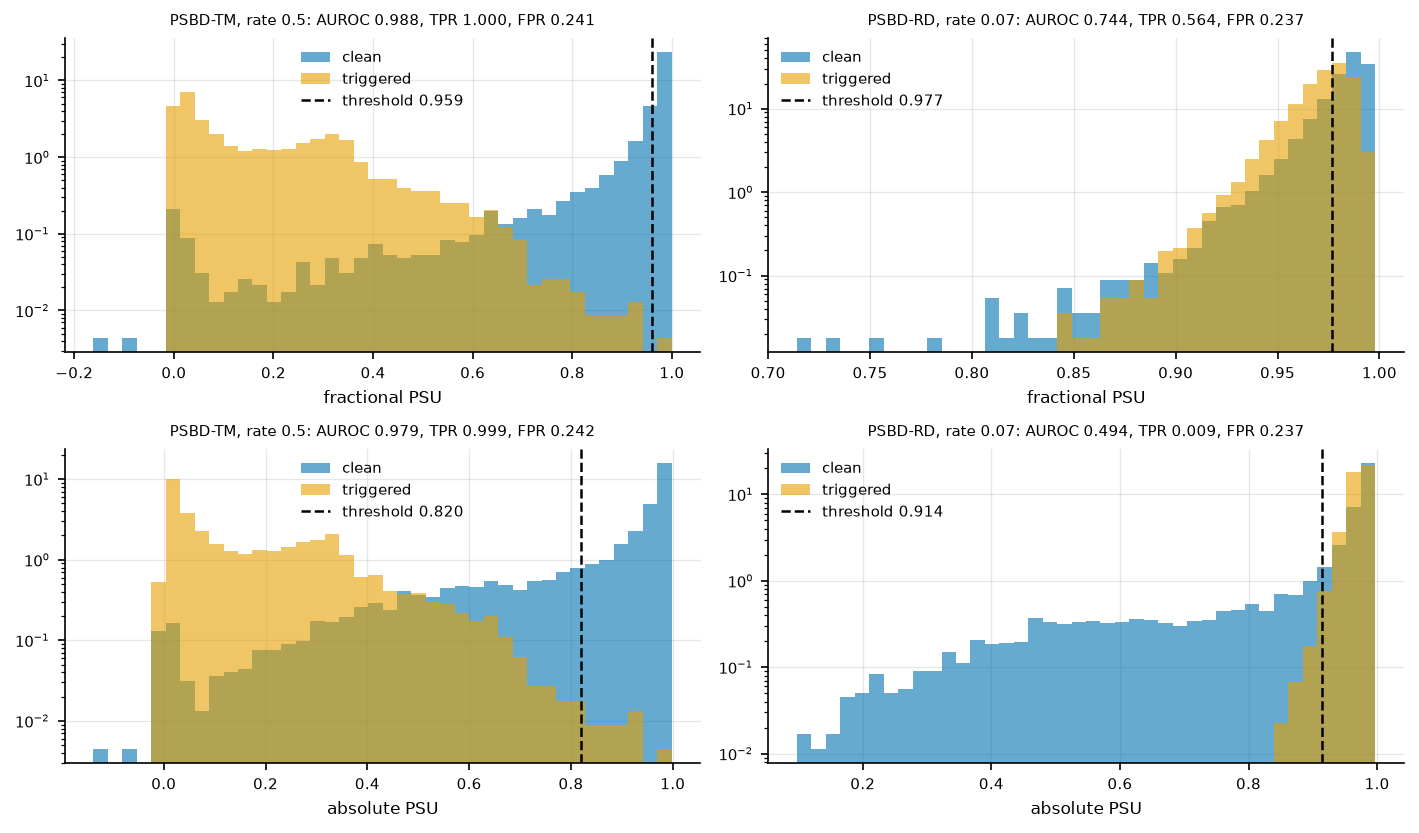

In [17]:
figure, axes = plt.subplots(2, 2, figsize=(9.5, 5.6))
for column, name in enumerate(PLACEMENTS):
    adaptive_rate = rule_frame.loc[name, "adaptive_rate"]
    measured = swept[name][adaptive_rate]
    for row, (score, label) in enumerate((("psu_ratio", "fractional PSU"), ("psu", "absolute PSU"))):
        axis = axes[row, column]
        clean_scores = pair_clean_to_backdoor(measured["clean"][score], manifest).numpy()
        backdoor_scores = measured["backdoor"][score].numpy()
        threshold = threshold_at_quantile(measured["validation"][score], HEADLINE_QUANTILE)
        bin_edges = np.histogram_bin_edges(np.concatenate([clean_scores, backdoor_scores]), bins=40)
        axis.hist(clean_scores, bins=bin_edges, density=True, alpha=0.6, label="clean")
        axis.hist(backdoor_scores, bins=bin_edges, density=True, alpha=0.6, label="triggered")
        axis.axvline(threshold, color="black", ls="--", lw=1.2, label=f"threshold {threshold:.3f}")
        report = report_at(name, adaptive_rate, HEADLINE_QUANTILE, score=score)
        axis.set_title(f"{name}, rate {adaptive_rate}: AUROC {report['auroc']:.3f}, TPR {report['tpr']:.3f}, FPR {report['fpr']:.3f}", fontsize=7)
        axis.set_xlabel(label)
        axis.set_yscale("log")
        axis.legend()
figure.tight_layout()
plt.show()

tm_report = report_at("PSBD-TM", rule_frame.loc["PSBD-TM", "adaptive_rate"], HEADLINE_QUANTILE)
rd_scores = swept["PSBD-RD"][rule_frame.loc["PSBD-RD", "adaptive_rate"]]
rd_overlap_low = float(min(rd_scores["backdoor"]["psu_ratio"].quantile(0.01), pair_clean_to_backdoor(rd_scores["clean"]["psu_ratio"], manifest).quantile(0.01)))
rd_absolute_triggered_higher = float(rd_scores["backdoor"]["psu"].median()) > float(pair_clean_to_backdoor(rd_scores["clean"]["psu"], manifest).median())

In [18]:
display(Markdown(rf"""
Under PSBD-TM triggered images pile up near 0, their probability untouched by the masks, while clean images spread to the right, so the threshold at the {HEADLINE_QUANTILE:.0%} validation quantile flags {tm_report["tpr"]:.1%} of triggered images and {tm_report["fpr"]:.1%} of clean ones. Under PSBD-RD the fractional scores of the 2 splits overlap across a narrow range (99% of both sit above {rd_overlap_low:.2f}), and the absolute scores put the median triggered image {"above" if rd_absolute_triggered_higher else "below"} the median clean one, {"the wrong side, because a confident prediction has the most probability to lose" if rd_absolute_triggered_higher else "the expected side"}, yet the 2 absolute distributions overlap so fully that their AUROC is {rd_absolute_at_adaptive:.3f}. The y axis is logarithmic so the thin tails stay visible. The histograms do not show which clean images score low, and the FPR on the analysis split only approximates the quantile set on validation, which the next figure measures across every quantile.
"""))


Under PSBD-TM triggered images pile up near 0, their probability untouched by the masks, while clean images spread to the right, so the threshold at the 25% validation quantile flags 100.0% of triggered images and 24.1% of clean ones. Under PSBD-RD the fractional scores of the 2 splits overlap across a narrow range (99% of both sit above 0.92), and the absolute scores put the median triggered image below the median clean one, the expected side, yet the 2 absolute distributions overlap so fully that their AUROC is 0.494. The y axis is logarithmic so the thin tails stay visible. The histograms do not show which clean images score low, and the FPR on the analysis split only approximates the quantile set on validation, which the next figure measures across every quantile.


## Every quantile at once

AUROC is threshold free, so it is identical at every quantile. Only TPR and FPR move with $\tau$. The quantile is the defender's only knob, and the FPR it produces on unseen clean images should track it, since validation and analysis images come from the same distribution.

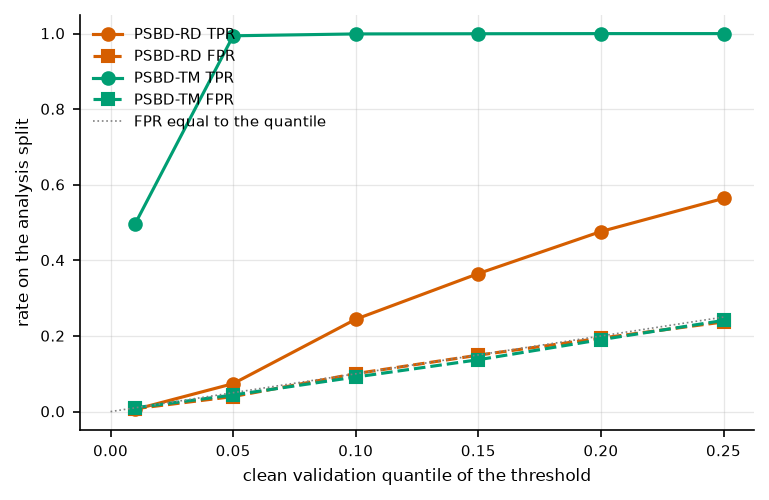

In [19]:
quantile_rows = []
for name in PLACEMENTS:
    adaptive_rate = rule_frame.loc[name, "adaptive_rate"]
    for quantile in PSBD_QUANTILES:
        quantile_rows.append({"placement": name, "quantile": quantile, **report_at(name, adaptive_rate, quantile)})
quantiles = pd.DataFrame(quantile_rows)

figure, axis = plt.subplots(figsize=(5.8, 3.6))
for name, rows in quantiles.groupby("placement"):
    axis.plot(rows["quantile"], rows["tpr"], marker="o", color=PLACEMENT_COLORS[name], label=f"{name} TPR")
    axis.plot(rows["quantile"], rows["fpr"], marker="s", ls="--", color=PLACEMENT_COLORS[name], label=f"{name} FPR")
axis.plot([0, 0.25], [0, 0.25], color="gray", lw=0.8, ls=":", label="FPR equal to the quantile")
axis.set_xlabel("clean validation quantile of the threshold")
axis.set_ylabel("rate on the analysis split")
axis.legend()
plt.show()
quantiles.set_index(["placement", "quantile"])[["threshold", "tpr", "fpr", "auroc"]].round(4)

fpr_error = float((quantiles["fpr"] - quantiles["quantile"]).abs().max())
tm_rows = quantiles[quantiles["placement"] == "PSBD-TM"].set_index("quantile")
rd_rows = quantiles[quantiles["placement"] == "PSBD-RD"].set_index("quantile")

In [20]:
display(Markdown(rf"""
Both FPR lines stay within {fpr_error:.3f} of the dotted diagonal, which is the direct evidence that the threshold does what it is asked. PSBD-TM flags {tm_rows.loc[0.05, "tpr"]:.3f} of triggered images at the 5% quantile and {tm_rows.loc[0.01, "tpr"]:.3f} at the 1% quantile, while PSBD-RD flags {rd_rows.loc[HEADLINE_QUANTILE, "tpr"]:.3f} even at the {HEADLINE_QUANTILE:.0%} quantile. The figure shows 1 model and does not show the low-budget TPR across the panel, which `\HeadlineTprAtOnePercent` reports ({macro("headline", "HeadlineTprAtOnePercent")} mean over the headline models at the 1% quantile, `paper/tables/headline.macros.json`).
"""))


Both FPR lines stay within 0.013 of the dotted diagonal, which is the direct evidence that the threshold does what it is asked. PSBD-TM flags 0.994 of triggered images at the 5% quantile and 0.497 at the 1% quantile, while PSBD-RD flags 0.564 even at the 25% quantile. The figure shows 1 model and does not show the low-budget TPR across the panel, which `\HeadlineTprAtOnePercent` reports (0.714 mean over the headline models at the 1% quantile, `paper/tables/headline.macros.json`).


## ROC curves

A ROC curve plots TPR against FPR as the threshold sweeps over every value, and AUROC is the area under it. It shows at a glance what the quantile table samples at 6 points.

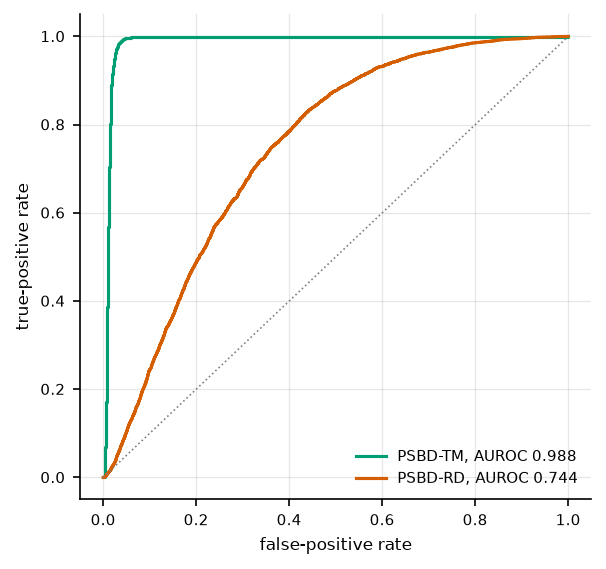

In [21]:
from sklearn.metrics import roc_curve

figure, axis = plt.subplots(figsize=(4.4, 4.2))
for name in PLACEMENTS:
    adaptive_rate = rule_frame.loc[name, "adaptive_rate"]
    measured = swept[name][adaptive_rate]
    clean_scores = pair_clean_to_backdoor(measured["clean"]["psu_ratio"], manifest).numpy()
    backdoor_scores = measured["backdoor"]["psu_ratio"].numpy()
    labels = np.concatenate([np.zeros(len(clean_scores)), np.ones(len(backdoor_scores))])  # (2 n_backdoor,)
    # Low PSU is the poisoned evidence, so the scores are negated as detection_report does.
    fpr, tpr, _ = roc_curve(labels, -np.concatenate([clean_scores, backdoor_scores]))
    axis.plot(fpr, tpr, color=PLACEMENT_COLORS[name], label=f"{name}, AUROC {rule_frame.loc[name, 'adaptive_auroc']:.3f}")
axis.plot([0, 1], [0, 1], color="gray", ls=":", lw=0.8)
axis.set_xlabel("false-positive rate")
axis.set_ylabel("true-positive rate")
axis.legend()
plt.show()

In [22]:
display(Markdown(rf"""
PSBD-TM's curve climbs close to TPR 1 at a small FPR, AUROC {rule_frame.loc["PSBD-TM", "adaptive_auroc"]:.3f}. PSBD-RD's curve stays well below it on this model, AUROC {rule_frame.loc["PSBD-RD", "adaptive_auroc"]:.3f}. The curves do not show how the numbers vary across models, which is the subject of every later notebook.
"""))


PSBD-TM's curve climbs close to TPR 1 at a small FPR, AUROC 0.988. PSBD-RD's curve stays well below it on this model, AUROC 0.744. The curves do not show how the numbers vary across models, which is the subject of every later notebook.


## Where a shifted clean prediction lands

The original paper explains PSU by neuron bias: under perturbation the network falls back on the classes its neurons favor, and the backdoor's neurons favor the target class most firmly, so a shifted clean prediction should land on the target more often than chance. `cli.analyze` records this per rate as `shift_target_histogram` and `clean_shift_to_target_fraction`. Here it is on this model, for both placements at their adaptive rates.

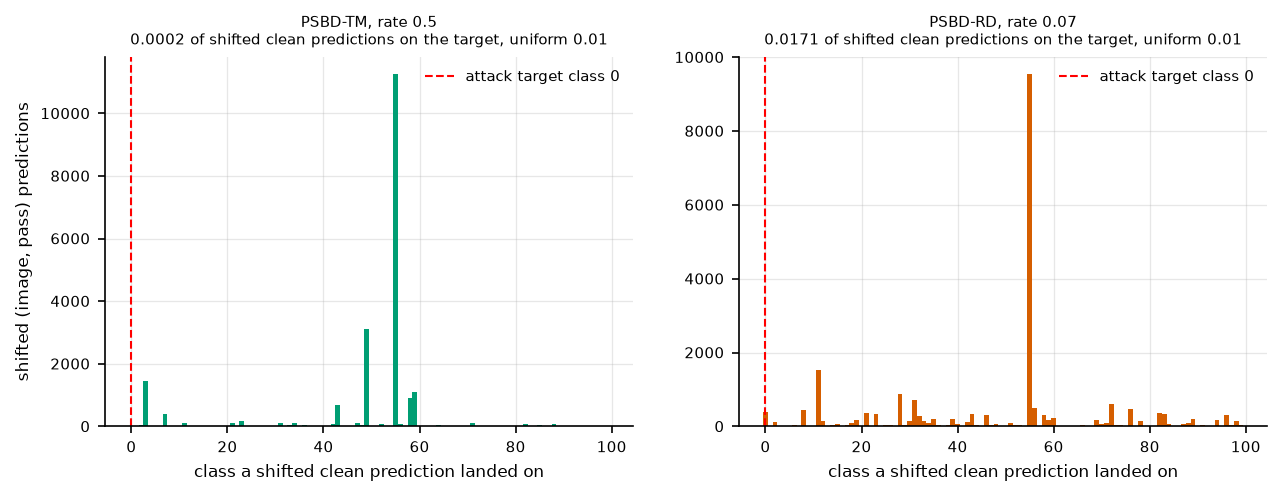

In [23]:
num_classes = spec.num_classes
target = manifest["probe_target_label"]
shift_shares, shift_top_class = {}, {}
figure, axes = plt.subplots(1, 2, figsize=(10.0, 3.2), sharey=False)
for axis, name in zip(axes, PLACEMENTS):
    adaptive_rate = rule_frame.loc[name, "adaptive_rate"]
    histogram = np.array(shift_target_histogram(baselines["clean"][1], swept[name][adaptive_rate]["clean"]["argmax"], num_classes))  # (classes,)
    axis.bar(range(num_classes), histogram, width=1.0, color=PLACEMENT_COLORS[name])
    axis.axvline(target, color="red", lw=1.0, ls="--", label=f"attack target class {target}")
    share = histogram[target] / histogram.sum()
    stored_row = next(row for row in stored_report["placements"][PLACEMENTS[name]]["rates"] if row["rate"] == adaptive_rate)
    assert abs(share - stored_row["clean_shift_to_target_fraction"]) < 1e-9
    shift_shares[name] = share
    shift_top_class[name] = int(histogram.argmax())
    axis.set_title(f"{name}, rate {adaptive_rate}\n{share:.4f} of shifted clean predictions on the target, uniform {1 / num_classes:.2f}", fontsize=7)
    axis.set_xlabel("class a shifted clean prediction landed on")
    axis.legend()
axes[0].set_ylabel("shifted (image, pass) predictions")
plt.show()

In [24]:
display(Markdown(rf"""
Under PSBD-TM {shift_shares["PSBD-TM"]:.4f} of shifted clean predictions land on the target class {target} and under PSBD-RD {shift_shares["PSBD-RD"]:.4f}, against a uniform {1 / num_classes:.2f}, so {"neither placement sends shifted clean predictions preferentially to the target" if max(shift_shares.values()) < 2 / num_classes else "at least 1 placement sends shifted clean predictions to the target more than twice as often as chance"}. Both pile onto a few default classes instead, class {shift_top_class["PSBD-TM"]} above all under PSBD-TM and class {shift_top_class["PSBD-RD"]} under PSBD-RD, the classes a perturbed ViT falls back on. On this model the neuron-bias account does not describe what the perturbation does. `mechanism.ipynb` and the hypothesis ledger (`docs/hypothesis/README.md`) test it across the panel, where the paper states it describes some attacks and not the statistic's mechanism.
"""))


Under PSBD-TM 0.0002 of shifted clean predictions land on the target class 0 and under PSBD-RD 0.0171, against a uniform 0.01, so neither placement sends shifted clean predictions preferentially to the target. Both pile onto a few default classes instead, class 55 above all under PSBD-TM and class 55 under PSBD-RD, the classes a perturbed ViT falls back on. On this model the neuron-bias account does not describe what the perturbation does. `mechanism.ipynb` and the hypothesis ledger (`docs/hypothesis/README.md`) test it across the panel, where the paper states it describes some attacks and not the statistic's mechanism.


## What this notebook establishes

Every box of the pipeline diagram was recomputed from the stage-1 cache with the library's own functions and landed on the numbers `cli.analyze` stored. On this 1 model, BadNets at 1% on CIFAR-100, PSBD-TM at its adaptive rate separates triggered from clean images almost perfectly while PSBD-RD barely does, and the reason is visible in the shift-ratio figure: token masking leaves triggered predictions in place at rates that move most clean ones. The question it leaves is whether this holds beyond 1 model and 1 attack, and whether the position or the operator is responsible, which `placement-walk.ipynb` answers on the panel.